In [1]:
%matplotlib inline
import os
os.environ["PYTHONPATH"] = "/home/cspark/Work/simulation_codes-working/radia/env/radia_python" #:" + os.environ.get("PYTHONPATH", "")

import sys
sys.path.append(os.environ["PYTHONPATH"])

import radia as rd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import pandas as pd
from uti_plot import *
from jupyter_rs_radia import radia_viewer
rd.UtiDelAll()
print("Radia Version is", rd.UtiVer())

Radia Version is 4.32


/home/cspark/Work/simulation_codes-working/miniforge3/envs/pyat-dev/lib/python3.11/site-packages/pykern/pkresource.py:14: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
#*********************************Plot the 3D Geometry
def PlotGeometry(x, y, z):
    # Current Densities in A/mm^2
    Imax = -3000

    # Define parameters
    x1 = x[0]; x2 = x[1]
    y1 = y[0]; y2 = y[1]
    z1 = z
    
    # Define coil corner points
    coils = [
        [[ x1, z1,  y1], [ x2, z1,  y2], [ x2, -z1,  y2], [ x1, -z1,  y1]],
        [[-x1, z1,  y1], [-x2, z1,  y2], [-x2, -z1,  y2], [-x1, -z1,  y1]],
        [[-x1, z1, -y1], [-x2, z1, -y2], [-x2, -z1, -y2], [-x1, -z1, -y1]],
        [[ x1, z1, -y1], [ x2, z1, -y2], [ x2, -z1, -y2], [ x1, -z1, -y1]]
    ]
    
    fig = plt.figure(figsize=(8, 16))
    ax = fig.add_subplot(111, projection='3d')

    # Add XY, YZ, and ZX planes with light shadow
    plane_alpha = 0.1
    xz_plane = [[[-15, -300, 0], [15, -300, 0], [15, 300, 0], [-15, 300, 0]]]
    zy_plane = [[[0, -300, -15], [0, -300, 15], [0, 300, 15], [0, 300, -15]]]
    yx_plane = [[[-15, 0, -15], [15, 0, -15], [15, 0, 15], [-15, 0, 15]]]
    
    ax.add_collection3d(Poly3DCollection(xz_plane, color='b', alpha=plane_alpha))
    ax.add_collection3d(Poly3DCollection(zy_plane, color='b', alpha=plane_alpha))
    ax.add_collection3d(Poly3DCollection(yx_plane, color='b', alpha=plane_alpha))

    # Add X, Y, Z axes
    ax.plot([-15, 15], [0, 0], [0, 0], 'k-', linewidth=1, label='X Axis')
    ax.plot([0, 0], [-300, 300], [0, 0], 'k-', linewidth=1, label='Z Axis')
    ax.plot([0, 0], [0, 0], [-15, 15], 'k-', linewidth=1, label='Y Axis')

    for coil in coils:
        poly = Poly3DCollection([coil], color='r', alpha=0.5, edgecolor='r', linewidth=5, facecolor='w')
        ax.add_collection3d(poly)
    
    ax.set_xlabel("X Axis (mm)")
    ax.set_ylabel("Z Axis (mm)")
    ax.set_zlabel("Y Axis (mm)")
    ax.set_title("3D Coil Geometry")
    ax.set_xlim(-15, 15)
    ax.set_ylim(-300, 300)
    ax.set_zlim(-15, 15)
    
    plt.show()

In [3]:
#*********************************Build the Geometry
def BuildGeometry(x, y, z):
    # Current Densities in A/mm^2
    Imax = -3000

    # Define parameters
    x1 = x[0]; x2 = x[1]
    y1 = y[0]; y2 = y[1]
    z1 = z
    
    # Define coil corner points
    p11 = [ x1, z1,  y1]; p12 = [ x2, z1,  y2]; p13 = [ x2, -z1,  y2]; p14 = [ x1, -z1,  y1]
    p21 = [-x1, z1,  y1]; p22 = [-x2, z1,  y2]; p23 = [-x2, -z1,  y2]; p24 = [-x1, -z1,  y1]
    p31 = [-x1, z1, -y1]; p32 = [-x2, z1, -y2]; p33 = [-x2, -z1, -y2]; p34 = [-x1, -z1, -y1]
    p41 = [ x1, z1, -y1]; p42 = [ x2, z1, -y2]; p43 = [ x2, -z1, -y2]; p44 = [ x1, -z1, -y1]
    
    # Create Coil Structures
    Rt1 = rd.ObjFlmCur([p11, p12, p13, p14, p11], Imax)
    Rt2 = rd.ObjFlmCur([p21, p22, p23, p24, p21], Imax)
    Rt3 = rd.ObjFlmCur([p31, p32, p33, p34, p31], Imax)
    Rt4 = rd.ObjFlmCur([p41, p42, p43, p44, p41], Imax)

    # Coil Presentation Parameters
    c2 = [1,0,0]; thcn = 0.001
    rd.ObjDrwAtr(Rt1, c2, thcn)
    rd.ObjDrwAtr(Rt2, c2, thcn)
    rd.ObjDrwAtr(Rt3, c2, thcn)
    rd.ObjDrwAtr(Rt4, c2, thcn)
    
    Grp = rd.ObjCnt([Rt1, Rt2, Rt3, Rt4])  # Ensure it's a list
    print("Final Number of Objects in Group:", len(rd.ObjCntStuf(Grp)))

    PlotGeometry(x, y, z)
    
    return Grp

Final Number of Objects in Group: 4


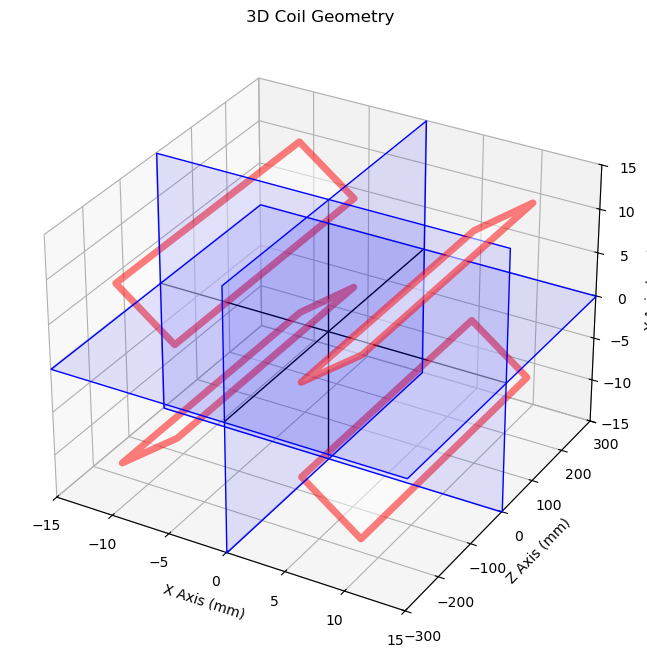

NKM Geometry Index: 21


In [4]:
# Build the Geometry
x = np.array([5.3, 10.250]); y = np.array([5.3, 10.250]); z = 262.5      #wire dimensions
nkm = BuildGeometry(x, y, z)
print('NKM Geometry Index:', nkm)

In [5]:
#*********************************Calculate Magnetic Field
def CalcField(g, x, z):
    # Define Mesh for Computation
    xMin, xMax, nx = -50, 50, 201  # mm
    zMin, zMax, nz = -z, z, 5  # mm (choose a few z locations)
    yVal = 0.0  # Fixed y location
    
    # Compute B_y(x, z) at y=0
    B_y_data = []
    z_locations = np.linspace(zMin, zMax, nz)
    x_locations = np.linspace(xMin, xMax, nx)
    
    for z in z_locations:
        B_y = [rd.Fld(g, 'bz', [x, z, yVal]) for x in x_locations]
        B_y_data.append(B_y)
    
    return B_y_data, x_locations, z_locations

In [6]:
def plot_B_y(B_y_results, x_vals, z_vals):
    """
    Plot B_y vs x for different z values.
    
    Parameters:
    - x_vals: numpy array of x positions
    - B_y_results: list of B_y arrays
    - z_vals: list of z values corresponding to B_y_results
    """
    fig, ax1 = plt.subplots(figsize=(8, 6))
    ax2 = ax1.twinx()
    markers = ['*', 'o', '+', '^', 'v']
    
    for i, B_y in enumerate(B_y_results):
        ax1.plot(x_vals, B_y, label=f"z = {z_vals[i]} mm", marker=markers[i], ms=3)
    
    # Adding points on secondary y-axis
    x_points = [x[0], x[1], -x[0], -x[1], -x[0], -x[1],  x[0],  x[1]]
    y_points = [y[0], y[1],  y[0],  y[1], -y[0], -y[1], -y[0], -y[1]]
    ax2.scatter(x_points, y_points, color='b', marker='o', label='Special Points')
    
    ax1.set_xlabel(r"$x$ (mm)")
    ax1.set_ylabel(r"$B_y$ (T)")
    ax1.set_title(r"Magnetic Field $B_y$ vs $x$ for different $z$ values at $y=0$")
    
    ax1.legend()
    #ax2.legend(loc='upper right')
    ax1.grid()
    
    plt.show()

In [7]:
def save_B_data(fname, B_y, vals):
    with open(fname, "w") as f:
        for i, x in enumerate(vals):
            f.write(f"{x*1e-3} " + f"{B_y[i]}" + "\n")

By at y = 0 and z = 0 has a maximum value of 0.146 T at x = 8.500 mm


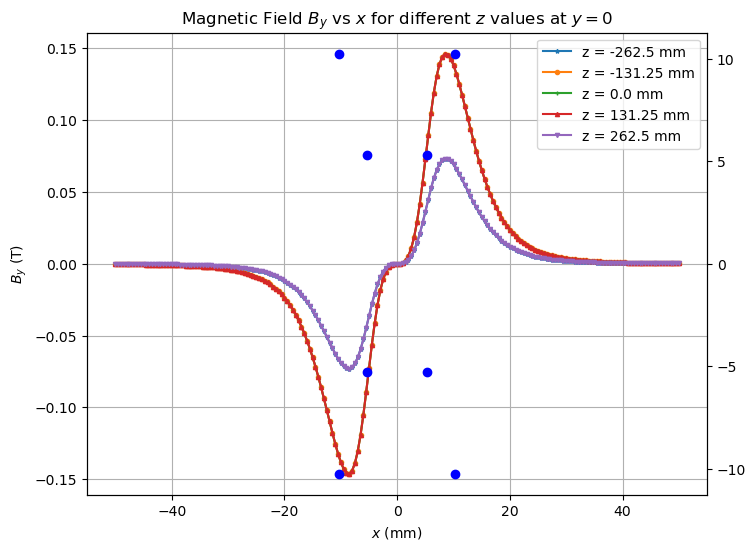

In [8]:
# Calculate Magnetic Field
B_y_data, x_vals, z_vals = CalcField(nkm, x, z)
save_B_data("By.txt", B_y_data[2], x_vals)
print(f"By at y = 0 and z = 0 has a maximum value of {np.max(B_y_data[2]):.3f} T at x = {x_vals[np.argmax(B_y_data[2])]:.3f} mm")
plot_B_y(B_y_data, x_vals, z_vals)

In [9]:
def CalcFieldInt(magnet, x):
    # Define Mesh for Computation
    xMin, xMax, nx = -50, 50, 201  # mm
    yVal = 0.0                     # Fixed y location
    
    # Compute int B_y dz at y=0
    x_locations = np.linspace(xMin, xMax, nx)
    iB_y = np.array([rd.FldInt(magnet, 'inf', 'ibz', [x, -300, yVal], [x, 300, yVal]) for x in x_locations])
    
    return iB_y, x_locations #, z_locations

In [10]:
def plot_iB_y(iB_y, x_vals):
    """
    Plot iB_y vs x for different z values.
    
    Parameters:
    - x_vals: numpy array of x positions
    - B_y_results: list of B_y arrays
    - z_vals: list of z values corresponding to B_y_results
    """
    fig, ax1 = plt.subplots(figsize=(8, 6))
    ax2 = ax1.twinx()

    energy_GeV = 4.0
    e_momentum = energy_GeV * 1e9 / 299792458  # Convert GeV to momentum
    #e_momentum = 1.0
    
    ax1.plot(x_vals, iB_y / e_momentum, ms=3, c='r')
    
    # Adding points on secondary y-axis
    x_points = [x[0], x[1], -x[0], -x[1], -x[0], -x[1],  x[0],  x[1]]
    y_points = [y[0], y[1],  y[0],  y[1], -y[0], -y[1], -y[0], -y[1]]
    ax2.scatter(x_points, y_points, color='b', marker='o', label='Special Points')
    
    ax1.set_xlabel(r"$x$ (mm)")
    ax1.set_ylabel(r"$\int B_{y} dz$ (T-m)")
    ax1.set_title(r"Magnetic Field $B_y$ vs $x$ at $y=0$")
    ax1.grid()
    
    plt.show()

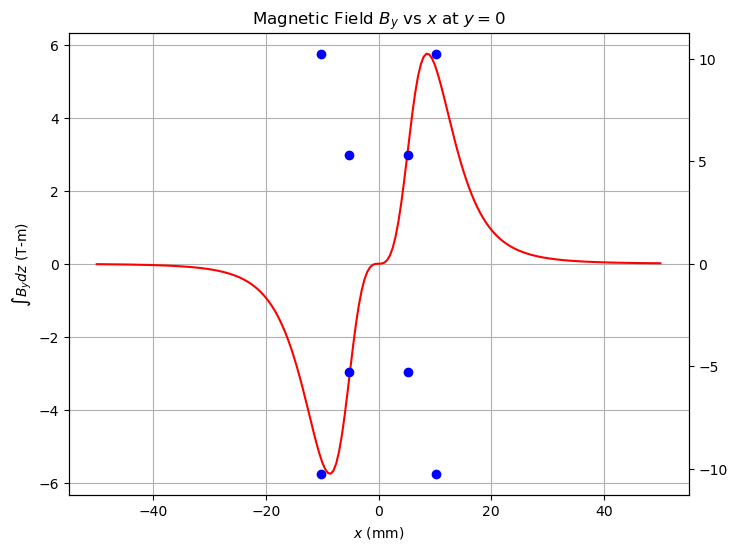

In [11]:
iB_y_data, x_vals= CalcFieldInt(nkm, x) #, z)
plot_iB_y(iB_y_data, x_vals) #, z_vals)